In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('Mharashtra_merged.csv')

# Drop rows where 'HCHO' or 'frp' are NaN
df = df.dropna(subset=['HCHO', 'frp'])

# Confirm it loaded correctly
print(f"Shape after dropping NaNs: {df.shape}")
df.head()


Shape after dropping NaNs: (2438, 13)


,Date,District,HCHO,CO,NO2,SO2,O3,frp,u10,v10,t2m,sp,blh
0,2025-01-01,Nandurbar,0.000192,0.040473,0.000020,0.000043,0.117468,7.79,-1.658227,-0.348315,294.831930,97725.092679,359.593090
4,2025-01-01,Buldana,0.000162,0.038853,0.000020,0.000036,0.119326,13.62,-0.661025,-1.370802,294.586919,96457.306506,369.449201
5,2025-01-01,Chandrapur,0.000139,0.042475,0.000055,0.000190,0.118403,2.80,-0.676691,-2.102157,295.074000,98934.271250,405.440930
6,2025-01-01,Dhule,0.000177,0.040699,0.000020,0.000023,0.118068,2.63,-1.548208,0.141153,295.000468,97646.266620,356.546959
8,2025-01-01,Jalgaon,0.000172,0.041190,0.000026,0.000058,0.119189,3.10,-1.450113,-0.635068,294.255145,98287.954583,334.020573


In [2]:
# Calculate the 95th percentile threshold for HCHO
threshold = df['HCHO'].quantile(0.95)

# Create boolean column: True if HCHO >= threshold
df['Is_Hotspot'] = df['HCHO'] >= threshold

# Print the threshold value
print(f"95th Percentile HCHO Threshold: {threshold:.6f}")
print(f"\nHotspot Summary:")
print(df['Is_Hotspot'].value_counts())
print(f"\nTotal Hotspots: {df['Is_Hotspot'].sum()} / {len(df)} rows ({df['Is_Hotspot'].mean()*100:.2f}%)")


95th Percentile HCHO Threshold: 0.000292

Hotspot Summary:
Is_Hotspot
False    2316
True      122
Name: count, dtype: int64

Total Hotspots: 122 / 2438 rows (5.00%)


In [3]:
# Convert u10/v10 wind vectors to real-world metrics

# Wind Speed: magnitude of the vector, converted from m/s to km/h
df['Wind_Speed_kmh'] = np.sqrt(df['u10']**2 + df['v10']**2) * 3.6

# Wind Direction: meteorological convention (direction wind is coming FROM)
df['Wind_Dir_Degrees'] = (270 - (180 / np.pi) * np.arctan2(df['v10'], df['u10'])) % 360

# --- Compass Direction ---
# Maps 0-360 degrees to one of 8 compass points.
# Returns None for NaN inputs (missing wind data).
def degrees_to_compass(deg):
    if pd.isna(deg):
        return None
    directions = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    idx = int((deg + 22.5) / 45) % 8
    return directions[idx]

df['Compass_Dir'] = df['Wind_Dir_Degrees'].apply(degrees_to_compass)

# Display results
print(f"Wind Speed  — min: {df['Wind_Speed_kmh'].min():.2f}, max: {df['Wind_Speed_kmh'].max():.2f}, mean: {df['Wind_Speed_kmh'].mean():.2f} km/h")
print(f"Wind Direction — min: {df['Wind_Dir_Degrees'].min():.2f}, max: {df['Wind_Dir_Degrees'].max():.2f} degrees")
print(f"Compass Dir   — unique values: {sorted(df['Compass_Dir'].dropna().unique())}")

df[['u10', 'v10', 'Wind_Speed_kmh', 'Wind_Dir_Degrees', 'Compass_Dir']].head()


Wind Speed  — min: 0.14, max: 25.71, mean: 5.89 km/h
Wind Direction — min: 0.54, max: 359.85 degrees
Compass Dir   — unique values: ['E', 'N', 'NE', 'NW', 'S', 'SE', 'SW', 'W']


,u10,v10,Wind_Speed_kmh,Wind_Dir_Degrees,Compass_Dir
0,-1.658227,-0.348315,6.099891,78.137326,E
4,-0.661025,-1.370802,5.478690,25.744203,NE
5,-0.676691,-2.102157,7.950196,17.843536,N
6,-1.548208,0.141153,5.596667,95.209369,E
8,-1.450113,-0.635068,5.699084,66.349268,NE


In [4]:
from scipy.stats import pearsonr

# =============================================
#  1. SAME-DAY CORRELATION: HCHO vs FRP
# =============================================
corr_same, p_same = pearsonr(df['HCHO'], df['frp'])

print("=" * 50)
print("   SAME-DAY: HCHO ↔ Fire Radiative Power")
print("=" * 50)
print(f"  Pearson r  : {corr_same:.4f}")
print(f"  P-Value    : {p_same:.4e}")
print(f"  Significant: {'✅ Yes (p < 0.05)' if p_same < 0.05 else '❌ No'}")
print("=" * 50)

# =============================================
#  2. TIME-LAGGED CORRELATION (1-day lag)
#     Does yesterday's fire activity predict
#     today's HCHO concentration?
# =============================================
df_sorted = df.sort_values(['District', 'Date']).copy()
df_sorted['frp_lag1'] = df_sorted.groupby('District')['frp'].shift(1)
df_lag = df_sorted.dropna(subset=['frp_lag1'])

corr_lag, p_lag = pearsonr(df_lag['HCHO'], df_lag['frp_lag1'])

print()
print("=" * 50)
print("   1-DAY LAG: Yesterday FRP → Today HCHO")
print("=" * 50)
print(f"  Pearson r  : {corr_lag:.4f}")
print(f"  P-Value    : {p_lag:.4e}")
print(f"  Significant: {'✅ Yes (p < 0.05)' if p_lag < 0.05 else '❌ No'}")
print(f"  Lag sample : {len(df_lag)} rows (after dropping first-day NaNs)")
print("=" * 50)

# =============================================
#  3. INTERPRETATION SUMMARY
# =============================================
print()
print("--- Interpretation ---")
if abs(corr_lag) > abs(corr_same):
    print("📈 The lagged correlation is STRONGER than same-day.")
    print("   → Fire smoke may take ~1 day to build measurable HCHO levels.")
else:
    print("📊 Same-day correlation is equal or stronger than the 1-day lag.")
    print("   → HCHO response to fire activity appears to be rapid / same-day.")

# =============================================
#  4. FRONTEND FORMATTING — round & stringify
#     before export so the dashboard gets
#     clean, human-readable values
# =============================================

# Round continuous numerics for a cleaner UI
df['Wind_Speed_kmh']   = df['Wind_Speed_kmh'].round(1)
df['Wind_Dir_Degrees'] = df['Wind_Dir_Degrees'].round(1)
df['frp']              = df['frp'].round(2)

# Format HCHO as scientific-notation strings (e.g. "1.9216e-04")
# avoids tiny floating-point clutter in JSON / table cells
df['HCHO'] = df['HCHO'].apply(lambda x: f"{x:.4e}")

# =============================================
#  5. EXPORT — Compass_Dir replaces raw degrees
# =============================================
ui_columns = ['Date', 'District', 'HCHO', 'Is_Hotspot',
              'frp', 'Wind_Speed_kmh', 'Compass_Dir']
df_ui = df[ui_columns].copy()

output_path = 'ui_ready_data.csv'
df_ui.to_csv(output_path, index=False)

print(f"\n✅ Exported {len(df_ui)} rows × {len(df_ui.columns)} columns to '{output_path}'")
print(f"   Columns: {list(df_ui.columns)}")
df_ui.head()


   SAME-DAY: HCHO ↔ Fire Radiative Power
  Pearson r  : 0.0883
  P-Value    : 1.2776e-05
  Significant: ✅ Yes (p < 0.05)

   1-DAY LAG: Yesterday FRP → Today HCHO
  Pearson r  : 0.0869
  P-Value    : 1.9767e-05
  Significant: ✅ Yes (p < 0.05)
  Lag sample : 2404 rows (after dropping first-day NaNs)

--- Interpretation ---
📊 Same-day correlation is equal or stronger than the 1-day lag.
   → HCHO response to fire activity appears to be rapid / same-day.

✅ Exported 2438 rows × 7 columns to 'ui_ready_data.csv'
   Columns: ['Date', 'District', 'HCHO', 'Is_Hotspot', 'frp', 'Wind_Speed_kmh', 'Compass_Dir']


,Date,District,HCHO,Is_Hotspot,frp,Wind_Speed_kmh,Compass_Dir
0,2025-01-01,Nandurbar,1.9216e-04,False,7.79,6.1,E
4,2025-01-01,Buldana,1.6230e-04,False,13.62,5.5,NE
5,2025-01-01,Chandrapur,1.3886e-04,False,2.80,8.0,N
6,2025-01-01,Dhule,1.7664e-04,False,2.63,5.6,E
8,2025-01-01,Jalgaon,1.7205e-04,False,3.10,5.7,NE


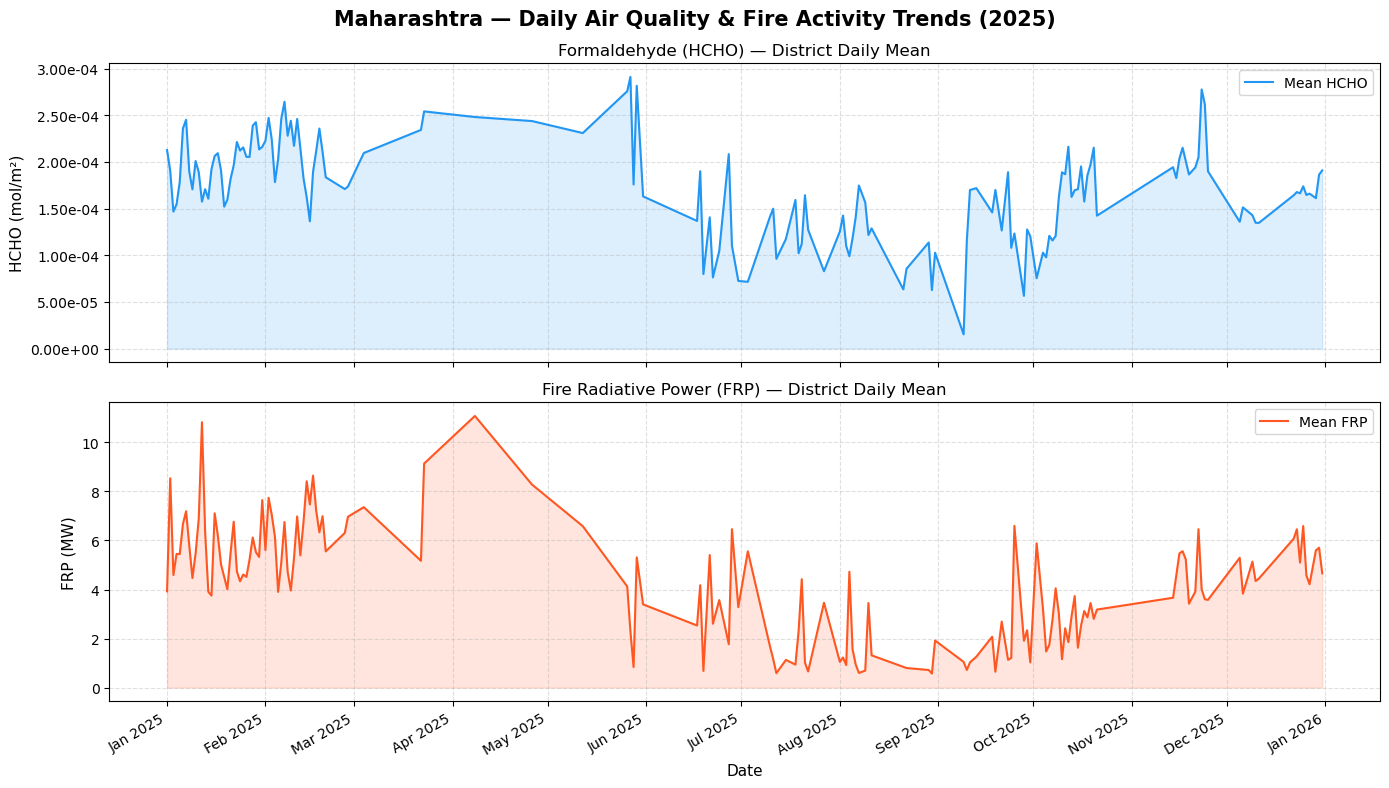

✅ Saved figure as 'trend_plots.png'


In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =============================================
#  TREND PLOTS: HCHO & FRP Over Time
# =============================================

# HCHO was converted to strings for the UI export — convert back to float for plotting
df_plot = df.copy()
df_plot['HCHO'] = pd.to_numeric(df_plot['HCHO'], errors='coerce')

# Group by Date and take the daily mean across all districts
daily = df_plot.groupby('Date').agg(
    HCHO_mean=('HCHO', 'mean'),
    frp_mean =('frp',  'mean')
).reset_index()

daily['Date'] = pd.to_datetime(daily['Date'])

# =============================================
#  FIGURE: two stacked subplots
# =============================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Maharashtra — Daily Air Quality & Fire Activity Trends (2025)',
             fontsize=15, fontweight='bold', y=0.98)

# --- Subplot 1: HCHO ---
ax1.plot(daily['Date'], daily['HCHO_mean'],
         color='#2196F3', linewidth=1.5, label='Mean HCHO')
ax1.fill_between(daily['Date'], daily['HCHO_mean'],
                 alpha=0.15, color='#2196F3')
ax1.set_ylabel('HCHO (mol/m²)', fontsize=11)
ax1.set_title('Formaldehyde (HCHO) — District Daily Mean', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2e}'))
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)

# --- Subplot 2: FRP ---
ax2.plot(daily['Date'], daily['frp_mean'],
         color='#FF5722', linewidth=1.5, label='Mean FRP')
ax2.fill_between(daily['Date'], daily['frp_mean'],
                 alpha=0.15, color='#FF5722')
ax2.set_ylabel('FRP (MW)', fontsize=11)
ax2.set_title('Fire Radiative Power (FRP) — District Daily Mean', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)

# --- Shared x-axis formatting ---
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.set_xlabel('Date', fontsize=11)

plt.tight_layout()
plt.savefig('trend_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved figure as 'trend_plots.png'")


In [6]:
import json

# =============================================
#  GEOJSON EXPORT — Maharashtra Hotspots
# =============================================

# Approximate central lat/lon for all 36 Maharashtra districts
DISTRICT_COORDS = {
    'Ahmednagar'  : (19.0948,  74.7480),
    'Akola'       : (20.7002,  77.0082),
    'Amravati'    : (20.9374,  77.7796),
    'Aurangabad'  : (19.8762,  75.3433),
    'Beed'        : (18.9890,  75.7601),
    'Bhandara'    : (21.1667,  79.6500),
    'Buldana'     : (20.5292,  76.1842),
    'Chandrapur'  : (19.9615,  79.2961),
    'Dhule'       : (20.9042,  74.7749),
    'Gadchiroli'  : (20.1809,  80.0000),
    'Gondia'      : (21.4628,  80.1947),
    'Hingoli'     : (19.7177,  77.1499),
    'Jalgaon'     : (21.0077,  75.5626),
    'Jalna'       : (19.8347,  75.8816),
    'Kolhapur'    : (16.7050,  74.2433),
    'Latur'       : (18.4088,  76.5604),
    'Mumbai City' : (18.9388,  72.8354),
    'Mumbai Suburban': (19.1136, 72.8697),
    'Nagpur'      : (21.1458,  79.0882),
    'Nanded'      : (19.1383,  77.3210),
    'Nandurbar'   : (21.3667,  74.2333),
    'Nashik'      : (19.9975,  73.7898),
    'Osmanabad'   : (18.1769,  76.0416),
    'Palghar'     : (19.6967,  72.7651),
    'Parbhani'    : (19.2704,  76.7748),
    'Pune'        : (18.5204,  73.8567),
    'Raigad'      : (18.5158,  73.1843),
    'Ratnagiri'   : (16.9944,  73.3000),
    'Sangli'      : (16.8524,  74.5815),
    'Satara'      : (17.6805,  74.0183),
    'Sindhudurg'  : (16.3498,  73.6500),
    'Solapur'     : (17.6599,  75.9064),
    'Thane'       : (19.2183,  72.9781),
    'Wardha'      : (20.7453,  78.6022),
    'Washim'      : (20.1092,  77.1330),
    'Yavatmal'    : (20.3888,  78.1204),
}

# --- Merge coordinates into df_ui ---
df_geo = df_ui.copy()
df_geo['Latitude']  = df_geo['District'].map(lambda d: DISTRICT_COORDS.get(d, (None, None))[0])
df_geo['Longitude'] = df_geo['District'].map(lambda d: DISTRICT_COORDS.get(d, (None, None))[1])

# Check for any districts that didn't match the lookup
unmatched = df_geo[df_geo['Latitude'].isna()]['District'].unique()
if len(unmatched) > 0:
    print(f"⚠️  Unmatched districts (no coords): {list(unmatched)}")

# --- Filter for hotspot rows only ---
hotspots = df_geo[df_geo['Is_Hotspot'] == True].dropna(subset=['Latitude', 'Longitude'])

# --- Build GeoJSON FeatureCollection ---
features = []
for _, row in hotspots.iterrows():
    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row['Longitude'], row['Latitude']]  # GeoJSON is [lon, lat]
        },
        "properties": {
            "date"          : str(row['Date']),
            "district"      : row['District'],
            "hcho"          : row['HCHO'],
            "frp"           : row['frp'],
            "wind_speed_kmh": row['Wind_Speed_kmh'],
            "compass_dir"   : row['Compass_Dir'],
            "is_hotspot"    : bool(row['Is_Hotspot'])
        }
    }
    features.append(feature)

geojson = {
    "type": "FeatureCollection",
    "features": features
}

# --- Save to file ---
output_path = 'hotspots.geojson'
with open(output_path, 'w') as f:
    json.dump(geojson, f, indent=2)

print(f"✅ Exported {len(features)} hotspot features to '{output_path}'")
print(f"   Districts covered: {hotspots['District'].nunique()}")
print(f"   Date range: {hotspots['Date'].min()} → {hotspots['Date'].max()}")

# Preview first feature
print("\n--- Sample Feature ---")
print(json.dumps(features[0], indent=2))


⚠️  Unmatched districts (no coords): ['Raigarh', 'Bid', 'Gondiya', 'Garhchiroli']
✅ Exported 97 hotspot features to 'hotspots.geojson'
   Districts covered: 23
   Date range: 2025-01-01 → 2025-12-30

--- Sample Feature ---
{
  "type": "Feature",
  "geometry": {
    "type": "Point",
    "coordinates": [
      73.3,
      16.9944
    ]
  },
  "properties": {
    "date": "2025-01-01",
    "district": "Ratnagiri",
    "hcho": "3.5127e-04",
    "frp": 4.38,
    "wind_speed_kmh": 5.1,
    "compass_dir": "NE",
    "is_hotspot": true
  }
}
